<a href="https://colab.research.google.com/github/BerPereira/mvp-puc-rio-medical-appointment-no-shows-bernardo/blob/main/BernardoCMAPereira_PUCRIO_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória e Pré-processamento de Dados para o Problema de Faltas em Consultas Médicas

## MVP da Sprint 1 — Análise de Dados e Boas Práticas

**Aluno:** Bernardo Correia de Miranda Alcântara Pereira

Este notebook apresenta o desenvolvimento do MVP da Sprint 1 da disciplina **Análise de Dados e Boas Práticas**, cobrindo as etapas de **definição do problema, análise exploratória de dados e pré-processamento**, conforme proposto no material da disciplina e no template disponibilizado pela PUC-Rio.

**Acesso ao notebook no Google Colab:** https://github.com/BerPereira/mvp-puc-rio-medical-appointment-no-shows-bernardo

**Dataset:** https://www.kaggle.com/datasets/joniarroba/noshowappointments


# 1. Introdução

Neste trabalho, desenvolvo o MVP da Sprint 1 da disciplina **Análise de Dados e Boas Práticas**, com foco nas etapas iniciais de um projeto de ciência de dados: **definição do problema, análise exploratória de dados e pré-processamento**.

O dataset escolhido foi o **Medical Appointment No Shows**, disponibilizado no Kaggle. A base reúne informações sobre consultas médicas agendadas e indica se o paciente compareceu ou não ao atendimento. Esse problema é relevante porque faltas em consultas prejudicam a eficiência do sistema de saúde, comprometem o aproveitamento da agenda médica e podem impactar o atendimento de outros pacientes.

A escolha desse dataset foi feita levando em consideração os requisitos do MVP. Trata-se de uma base pública, adequada para análise exploratória e pré-processamento, com variáveis numéricas, categóricas, binárias e temporais. Além disso, com base nos materiais da sprint, esse dataset não foi utilizado nas aulas práticas da disciplina.

Ao longo deste notebook, apresento a formulação do problema, hipóteses iniciais, análise dos atributos, exploração estatística e visual dos dados, identificação de problemas de qualidade e aplicação de operações de pré-processamento justificadas.

# 2. Definição do problema

O problema analisado neste trabalho é a **ausência de pacientes em consultas médicas previamente agendadas**. Esse fenômeno, conhecido como *no-show*, afeta diretamente a eficiência operacional de instituições de saúde, pois gera desperdício de agenda, reduz o aproveitamento do atendimento disponível e pode aumentar o tempo de espera de outros pacientes.

A proposta deste MVP é investigar os dados disponíveis para entender melhor esse problema e identificar padrões que pareçam estar associados ao não comparecimento. Como esta sprint está focada nas etapas iniciais do projeto, o objetivo aqui não é treinar um modelo final, mas sim compreender os dados, levantar hipóteses, identificar problemas de qualidade e preparar uma versão tratada da base para etapas futuras.

A pergunta central deste trabalho é:

**Quais características dos pacientes e dos agendamentos parecem estar associadas ao não comparecimento às consultas médicas?**

## 2.1 Tipo de problema

Este problema pode ser caracterizado como um problema de **aprendizado supervisionado de classificação**. Isso ocorre porque o dataset possui uma variável alvo que indica se o paciente compareceu ou não à consulta, permitindo classificar cada registro em uma das duas classes possíveis.

Ainda que o foco deste MVP não seja a modelagem, essa caracterização é importante porque orienta a forma de analisar os dados e o tipo de pré-processamento que poderá ser útil em etapas posteriores.

## 2.2 Hipóteses iniciais

Antes de iniciar a análise exploratória, defini algumas hipóteses iniciais sobre o problema:

1. Pacientes com maior tempo de espera entre o agendamento e a consulta tendem a faltar mais.
2. O recebimento de SMS pode estar associado a uma menor taxa de ausência.
3. A taxa de não comparecimento pode variar entre bairros.
4. A idade do paciente pode influenciar o comparecimento à consulta.
5. Pacientes com determinadas condições de saúde podem apresentar comportamento diferente em relação à presença.
6. A variável alvo pode apresentar desequilíbrio entre as classes de comparecimento e ausência.

Essas hipóteses serão reavaliadas ao final do notebook com base nos resultados obtidos na análise exploratória e no pré-processamento.

## 2.3 Critérios de seleção do dataset

A escolha do dataset foi feita com base em alguns critérios importantes para este MVP:

- a base precisava ser **pública** e de fácil acesso;
- o dataset não poderia ter sido utilizado nas aulas da sprint;
- os dados deveriam permitir uma análise exploratória rica;
- a base deveria conter atributos suficientes para justificar diferentes operações de pré-processamento;
- o problema deveria ser claro e relevante do ponto de vista analítico.

O dataset **Medical Appointment No Shows** atende bem a esses critérios, pois apresenta variáveis numéricas, categóricas, binárias e temporais, além de uma variável alvo bem definida.

# 3. Fonte dos dados

O dataset utilizado neste trabalho é o **Medical Appointment No Shows**, obtido a partir da plataforma **Kaggle**.

A base contém informações sobre consultas médicas agendadas e registra se o paciente compareceu ou não ao atendimento. Para a entrega final do MVP, o dataset deverá ser disponibilizado de forma reprodutível, de preferência por meio de uma URL *raw* em um repositório público no GitHub, conforme recomendado nas orientações da atividade.

## 3.1 Descrição dos atributos

A seguir, apresento uma breve descrição dos principais atributos do dataset:

- **PatientId**: identificador do paciente.
- **AppointmentID**: identificador da consulta/agendamento.
- **Gender**: sexo do paciente.
- **ScheduledDay**: data e horário em que a consulta foi agendada.
- **AppointmentDay**: data da consulta.
- **Age**: idade do paciente.
- **Neighbourhood**: bairro associado ao atendimento.
- **Scholarship**: indicação de benefício social.
- **Hipertension**: indicação de hipertensão.
- **Diabetes**: indicação de diabetes.
- **Alcoholism**: indicação de alcoolismo.
- **Handcap**: indicação de deficiência.
- **SMS_received**: indica se o paciente recebeu SMS.
- **No-show**: variável alvo, indicando se o paciente faltou à consulta.

Esses atributos serão analisados individualmente e em conjunto ao longo do notebook, buscando entender sua distribuição, possíveis inconsistências e sua relação com o não comparecimento.

# 4. Importação das bibliotecas

Nesta seção, importo as bibliotecas que serão utilizadas ao longo do notebook. A organização das importações no início do trabalho contribui para a clareza, reprodutibilidade e execução adequada do código.

In [165]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 5. Carga dos dados

Nesta etapa, realizo a leitura do dataset e faço uma inspeção inicial da base, observando suas primeiras linhas, dimensões e tipos de dados. Esse primeiro contato é importante para verificar se a carga foi feita corretamente e para começar a entender a estrutura geral da base.

In [166]:
URL_DADOS = "https://raw.githubusercontent.com/BerPereira/mvp-puc-rio-medical-appointment-no-shows-bernardo/main/KaggleV2-May-2016.csv"

df_original = pd.read_csv(URL_DADOS)
df = df_original.copy()

print("Dataset carregado com sucesso.")
print(f"Shape inicial: {df.shape}")
display(df.head())

Dataset carregado com sucesso.
Shape inicial: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296.00,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.00,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.00,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.00,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.00,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [167]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
)

print("Colunas padronizadas:")
print(df.columns.tolist())

Colunas padronizadas:
['patientid', 'appointmentid', 'gender', 'scheduledday', 'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show']


In [168]:
mapa_colunas = {
    "patientid": "id_paciente",
    "appointmentid": "id_consulta",
    "gender": "genero",
    "scheduledday": "data_agendamento",
    "appointmentday": "data_consulta",
    "age": "idade",
    "neighbourhood": "bairro",
    "scholarship": "bolsa_familia",
    "hipertension": "hipertensao",
    "diabetes": "diabetes",
    "alcoholism": "alcoolismo",
    "handcap": "deficiencia",
    "sms_received": "sms_recebido",
    "no_show": "faltou"
}

df.rename(columns=mapa_colunas, inplace=True)

print("Colunas após renomeação:")
print(df.columns.tolist())

Colunas após renomeação:
['id_paciente', 'id_consulta', 'genero', 'data_agendamento', 'data_consulta', 'idade', 'bairro', 'bolsa_familia', 'hipertensao', 'diabetes', 'alcoolismo', 'deficiencia', 'sms_recebido', 'faltou']


In [169]:
df["data_agendamento"] = pd.to_datetime(df["data_agendamento"], errors="coerce")
df["data_consulta"] = pd.to_datetime(df["data_consulta"], errors="coerce")

df["faltou"] = df["faltou"].map({"No": 0, "Yes": 1})

colunas_binarias = ["bolsa_familia", "hipertensao", "diabetes", "alcoolismo", "deficiencia", "sms_recebido", "faltou"]
for coluna in colunas_binarias:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print("Tipos após conversões:")
display(df.dtypes)

Tipos após conversões:


,0
id_paciente,float64
id_consulta,int64
genero,object
data_agendamento,"datetime64[ns, UTC]"
data_consulta,"datetime64[ns, UTC]"
idade,int64
bairro,object
bolsa_familia,int64
hipertensao,int64
diabetes,int64


## 5.1 Primeiras impressões sobre a base

Após carregar o dataset, observo a quantidade de linhas e colunas, os nomes dos atributos e os tipos de dados presentes. Essa etapa é importante para identificar possíveis necessidades de ajuste logo no início, como conversão de tipos, renomeação de colunas ou tratamento de atributos que não parecem úteis para análises futuras.

In [170]:
print("Informações gerais da base:")
print("-" * 60)
df.info()

print("\nTipos de dados:")
display(df.dtypes)

print("\nQuantidade de linhas e colunas:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Informações gerais da base:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   id_paciente       110527 non-null  float64            
 1   id_consulta       110527 non-null  int64              
 2   genero            110527 non-null  object             
 3   data_agendamento  110527 non-null  datetime64[ns, UTC]
 4   data_consulta     110527 non-null  datetime64[ns, UTC]
 5   idade             110527 non-null  int64              
 6   bairro            110527 non-null  object             
 7   bolsa_familia     110527 non-null  int64              
 8   hipertensao       110527 non-null  int64              
 9   diabetes          110527 non-null  int64              
 10  alcoolismo        110527 non-null  int64              
 11  deficiencia    

,0
id_paciente,float64
id_consulta,int64
genero,object
data_agendamento,"datetime64[ns, UTC]"
data_consulta,"datetime64[ns, UTC]"
idade,int64
bairro,object
bolsa_familia,int64
hipertensao,int64
diabetes,int64



Quantidade de linhas e colunas:
Linhas: 110527
Colunas: 14


# 6. Análise exploratória de dados

A análise exploratória de dados é uma etapa crítica em projetos de ciência de dados, pois permite compreender melhor a base antes de qualquer tentativa de modelagem. Nesta seção, investigo a estrutura dos dados, suas estatísticas descritivas, distribuições, possíveis inconsistências, valores faltantes, outliers e relações entre atributos.

Além disso, procuro interpretar cada gráfico e cada tabela gerada, destacando os principais insights observados.

## 6.1 Quantidade de atributos e instâncias

Nesta subseção, verifico o número total de instâncias e atributos presentes no dataset. Essa informação é importante para entender o porte da base e orientar as próximas etapas da análise.

In [171]:
quantidade_linhas, quantidade_colunas = df.shape

print(f"Quantidade de instâncias: {quantidade_linhas}")
print(f"Quantidade de atributos: {quantidade_colunas}")

Quantidade de instâncias: 110527
Quantidade de atributos: 14


## 6.2 Tipos de dados

Aqui, observo os tipos de dados de cada coluna do dataset. Essa verificação é importante porque a escolha das análises e transformações depende diretamente do tipo de cada variável. Além disso, atributos temporais e categóricos podem exigir tratamentos específicos antes de serem utilizados em análises mais aprofundadas.

In [172]:
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_temporais = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
colunas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)

print("\nColunas temporais:")
print(colunas_temporais)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['id_paciente', 'id_consulta', 'idade', 'bolsa_familia', 'hipertensao', 'diabetes', 'alcoolismo', 'deficiencia', 'sms_recebido', 'faltou']

Colunas temporais:
['data_agendamento', 'data_consulta']

Colunas categóricas:
['genero', 'bairro']


## 6.3 Estatísticas descritivas

Nesta etapa, analiso as estatísticas descritivas dos atributos numéricos, incluindo medidas como mínimo, máximo, média, mediana e desvio-padrão. Essas medidas ajudam a entender a distribuição geral dos dados, identificar possíveis valores extremos e verificar se há comportamentos inesperados em algumas variáveis.

In [173]:
def calcular_estatisticas_descritivas(dataframe, colunas):
    resultados = []

    for coluna in colunas:
        serie = dataframe[coluna]
        moda = serie.mode(dropna=True)
        valor_moda = moda.iloc[0] if not moda.empty else np.nan

        resultados.append({
            "atributo": coluna,
            "quantidade_nao_nulos": serie.count(),
            "quantidade_ausentes": serie.isna().sum(),
            "media": serie.mean(),
            "mediana": serie.median(),
            "moda": valor_moda,
            "minimo": serie.min(),
            "maximo": serie.max(),
            "desvio_padrao": serie.std()
        })

    return pd.DataFrame(resultados)

estatisticas_numericas = calcular_estatisticas_descritivas(df, colunas_numericas)
display(estatisticas_numericas)

,atributo,quantidade_nao_nulos,quantidade_ausentes,media,mediana,moda,minimo,maximo,desvio_padrao
0,id_paciente,110527,0,147496265710394.06,31731838713978.00,822145925426128.00,39217.84,999981631772427.00,256094920291738.88
1,id_consulta,110527,0,5675305.12,5680573.00,5030230.00,5030230.00,5790484.00,71295.75
2,idade,110527,0,37.09,37.00,0.00,-1.00,115.00,23.11
3,bolsa_familia,110527,0,0.10,0.00,0.00,0.00,1.00,0.30
4,hipertensao,110527,0,0.20,0.00,0.00,0.00,1.00,0.40
5,diabetes,110527,0,0.07,0.00,0.00,0.00,1.00,0.26
6,alcoolismo,110527,0,0.03,0.00,0.00,0.00,1.00,0.17
7,deficiencia,110527,0,0.02,0.00,0.00,0.00,4.00,0.16
8,sms_recebido,110527,0,0.32,0.00,0.00,0.00,1.00,0.47
9,faltou,110527,0,0.20,0.00,0.00,0.00,1.00,0.40


### Interpretação inicial das estatísticas

A análise das estatísticas descritivas permite identificar a amplitude dos valores, a dispersão dos dados e possíveis sinais de inconsistência. Caso sejam observados valores incompatíveis com o domínio do problema, isso pode indicar a necessidade de tratamento durante a etapa de pré-processamento.

## 6.4 Verificação de valores faltantes

Nesta subseção, verifico a presença de valores ausentes em cada coluna do dataset. A identificação de dados faltantes é importante porque esse tipo de problema pode comprometer análises, gerar interpretações distorcidas e afetar etapas futuras do projeto.

Dependendo da quantidade e da natureza dos valores faltantes, diferentes estratégias poderão ser adotadas posteriormente, como remoção, imputação ou manutenção controlada dos dados.

In [174]:
valores_faltantes = pd.DataFrame({
    "atributo": df.columns,
    "quantidade_ausentes": df.isna().sum().values,
    "percentual_ausentes": (df.isna().sum().values / len(df)) * 100
}).sort_values(by="quantidade_ausentes", ascending=False)

display(valores_faltantes)

print("Total geral de valores ausentes na base:", df.isna().sum().sum())

,atributo,quantidade_ausentes,percentual_ausentes
0,id_paciente,0,0.00
1,id_consulta,0,0.00
2,genero,0,0.00
3,data_agendamento,0,0.00
4,data_consulta,0,0.00
5,idade,0,0.00
6,bairro,0,0.00
7,bolsa_familia,0,0.00
8,hipertensao,0,0.00
9,diabetes,0,0.00


Total geral de valores ausentes na base: 0


## 6.5 Verificação de duplicados

Aqui, investigo a existência de registros duplicados. Essa análise é importante porque duplicações indevidas podem distorcer frequências, proporções e conclusões. Ao mesmo tempo, é necessário interpretar com cuidado esse resultado, pois a repetição de pacientes, por exemplo, não significa necessariamente erro, já que um mesmo paciente pode ter múltiplas consultas registradas.

In [175]:
duplicados_completos = df.duplicated().sum()
duplicados_id_consulta = df["id_consulta"].duplicated().sum()
duplicados_id_paciente = df["id_paciente"].duplicated().sum()

print(f"Duplicados completos: {duplicados_completos}")
print(f"Duplicados em id_consulta: {duplicados_id_consulta}")
print(f"Duplicados em id_paciente: {duplicados_id_paciente}")

Duplicados completos: 0
Duplicados em id_consulta: 0
Duplicados em id_paciente: 48228


## 6.6 Análise da variável alvo

Nesta etapa, analiso a distribuição da variável alvo, isto é, a proporção entre pacientes que compareceram e pacientes que faltaram à consulta. Essa análise é importante porque ajuda a entender o comportamento geral do problema e também permite verificar se existe desequilíbrio entre as classes.

,classe,quantidade,percentual
0,Compareceu,88208,79.81
1,Faltou,22319,20.19


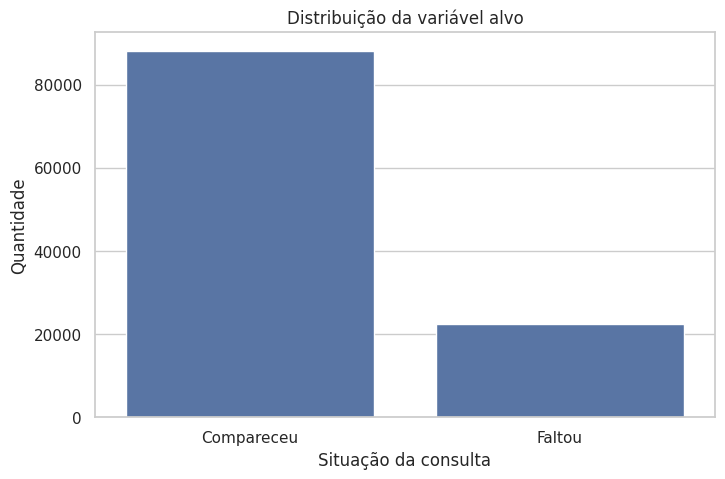

In [176]:
distribuicao_alvo = (
    df["faltou"]
    .value_counts(dropna=False)
    .rename(index={0: "Compareceu", 1: "Faltou"})
    .reset_index()
)
distribuicao_alvo.columns = ["classe", "quantidade"]
distribuicao_alvo["percentual"] = (distribuicao_alvo["quantidade"] / distribuicao_alvo["quantidade"].sum()) * 100

display(distribuicao_alvo)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="faltou")
ax.set_xticklabels(["Compareceu", "Faltou"])
ax.set_title("Distribuição da variável alvo")
ax.set_xlabel("Situação da consulta")
ax.set_ylabel("Quantidade")
plt.show()

### Comentário sobre a variável alvo

A distribuição entre comparecimento e ausência é um ponto central deste trabalho. Caso exista um desequilíbrio muito forte entre as classes, isso deverá ser considerado em etapas futuras do projeto, especialmente se houver continuidade para modelagem preditiva.

## 6.7 Distribuição das variáveis numéricas

Nesta subseção, examino a distribuição das variáveis numéricas por meio de histogramas e boxplots. Esse tipo de visualização é útil para identificar assimetria, concentração de valores, dispersão e possíveis outliers.

No contexto deste dataset, a variável **Age** merece atenção especial, já que idades muito baixas, negativas ou excessivamente altas podem indicar inconsistências ou situações que precisam ser analisadas com mais cuidado.

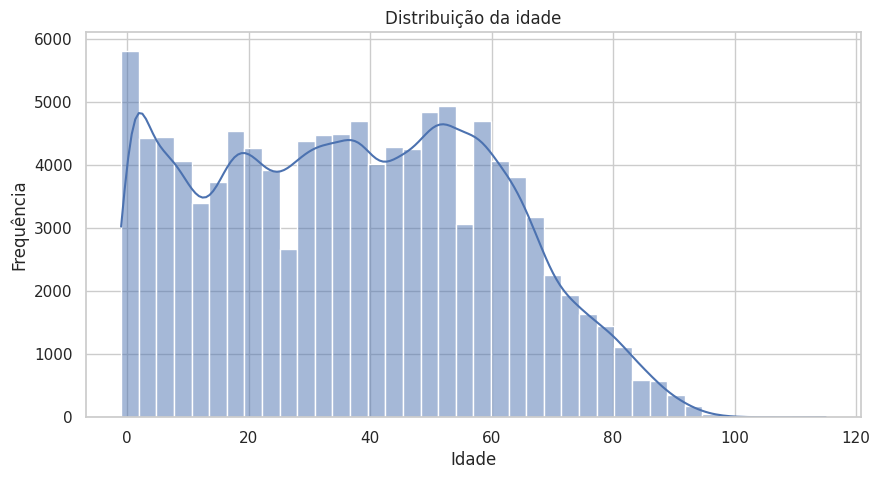

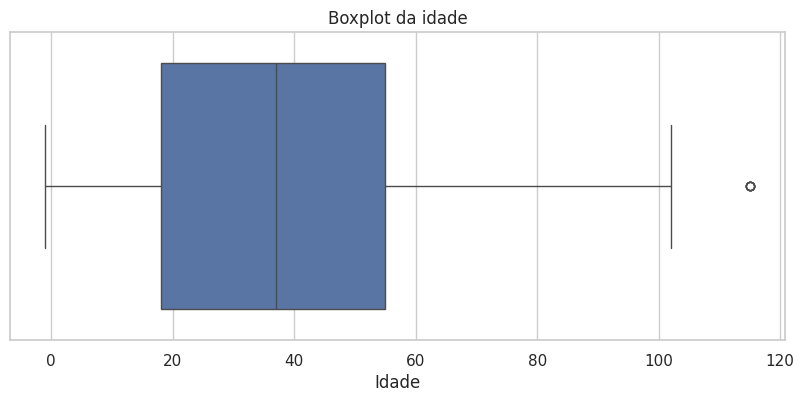

In [177]:
plt.figure(figsize=(10, 5))
sns.histplot(df["idade"], bins=40, kde=True)
plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["idade"])
plt.title("Boxplot da idade")
plt.xlabel("Idade")
plt.show()

In [178]:
print("Resumo da idade:")
display(df["idade"].describe())

print("Registros com idade negativa:")
display(df[df["idade"] < 0].head())

print("Registros com idade acima de 100:")
display(df[df["idade"] > 100].head())

Resumo da idade:


,idade
count,110527.00
mean,37.09
std,23.11
min,-1.00
25%,18.00
50%,37.00
75%,55.00
max,115.00


Registros com idade negativa:


,id_paciente,id_consulta,genero,data_agendamento,data_consulta,idade,bairro,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou
99832,465943158731293.00,5775010,F,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃO,0,0,0,0,0,0,0


Registros com idade acima de 100:


,id_paciente,id_consulta,genero,data_agendamento,data_consulta,idade,bairro,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou
58014,976294799775439.00,5651757,F,2016-05-03 09:14:53+00:00,2016-05-03 00:00:00+00:00,102,CONQUISTA,0,0,0,0,0,0,0
63912,31963211613981.00,5700278,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,1
63915,31963211613981.00,5700279,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,1
68127,31963211613981.00,5562812,F,2016-04-08 14:29:17+00:00,2016-05-16 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,1
76284,31963211613981.00,5744037,F,2016-05-30 09:44:51+00:00,2016-05-30 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,0


## 6.8 Distribuição das variáveis categóricas e binárias

Aqui, analiso a frequência das variáveis categóricas e binárias do dataset. O objetivo é entender a composição da base e verificar se existem categorias predominantes, categorias raras ou distribuições muito desequilibradas.

Essa etapa é importante porque pode revelar padrões relevantes para o problema e também orientar decisões de pré-processamento, como agrupamentos, recodificações ou transformações futuras.

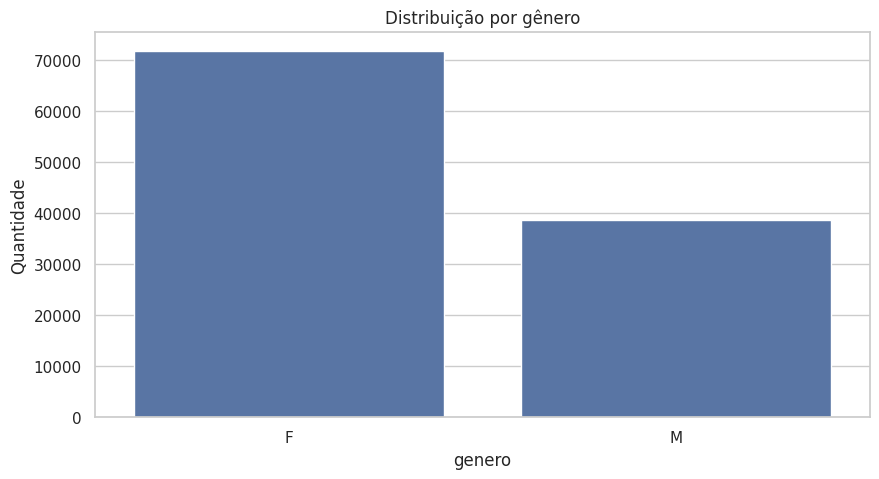

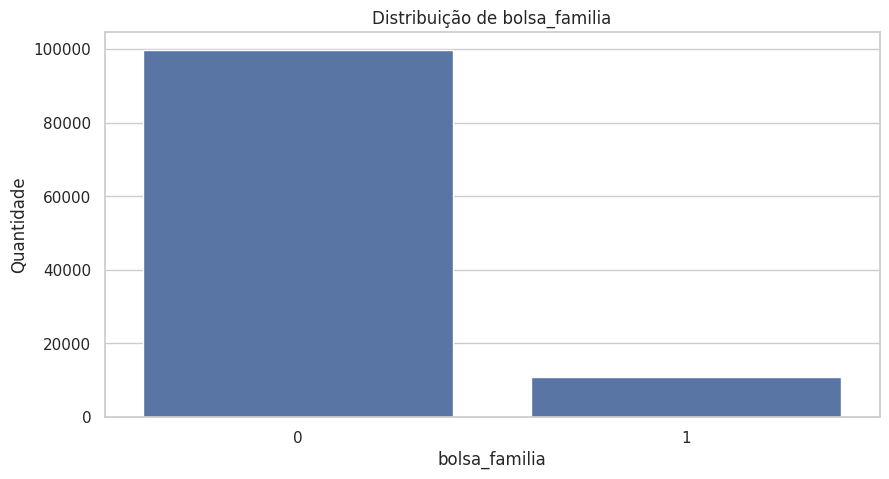

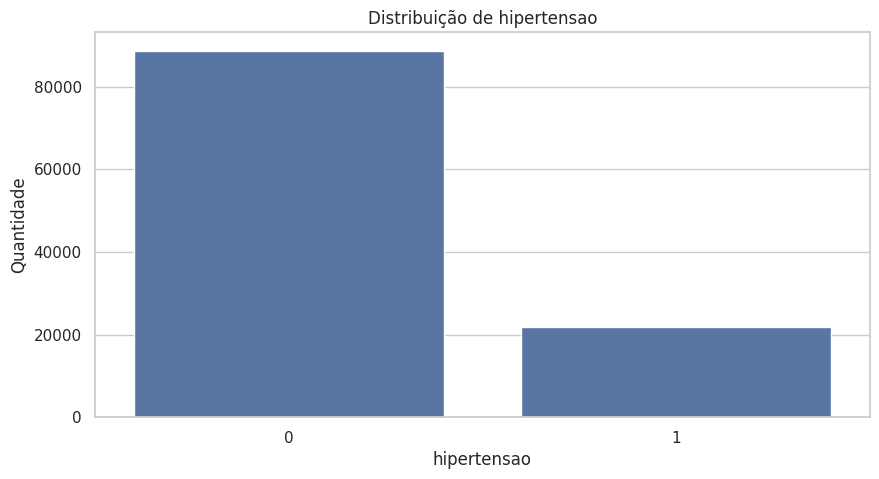

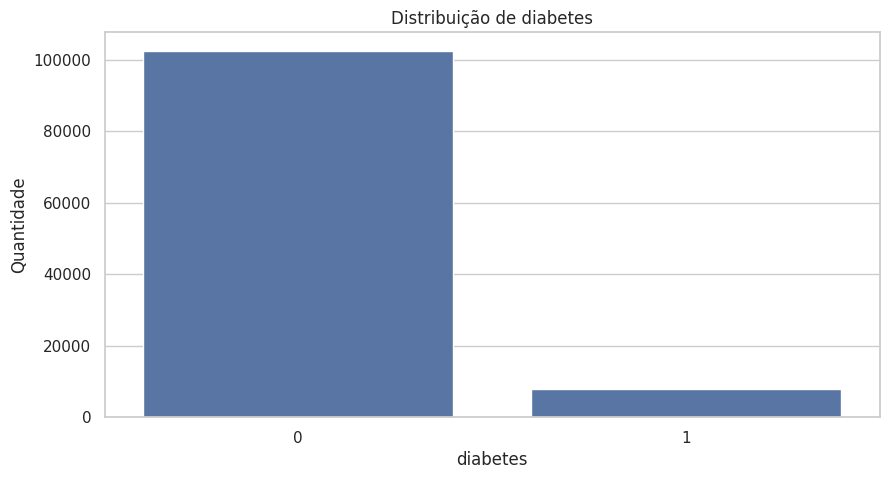

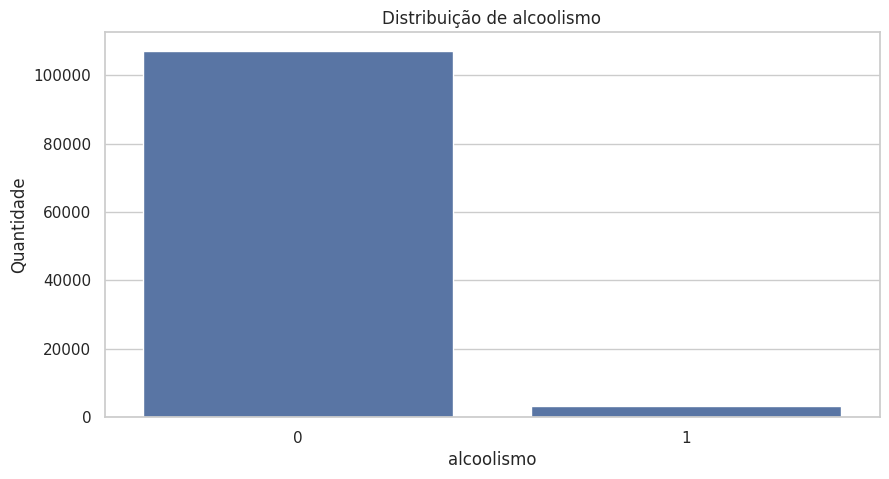

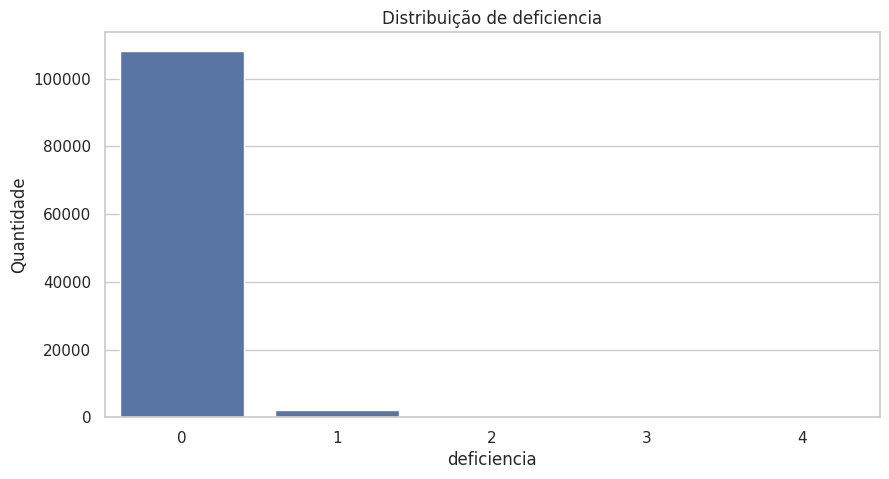

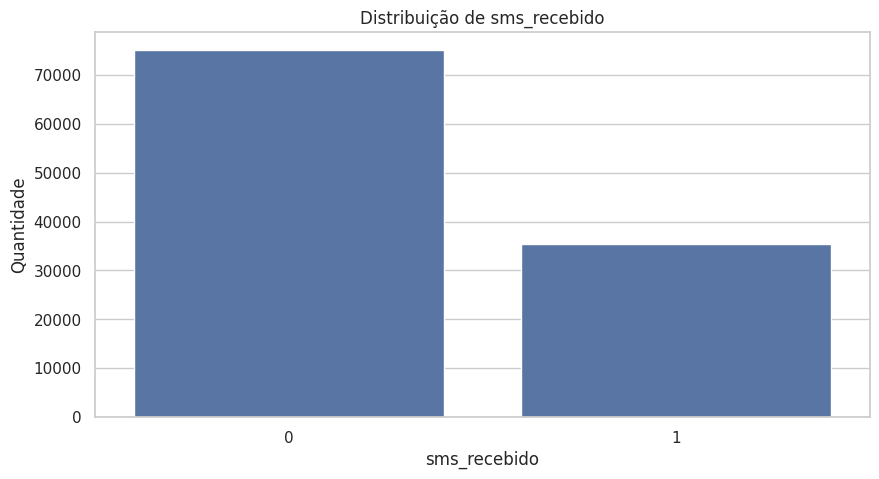

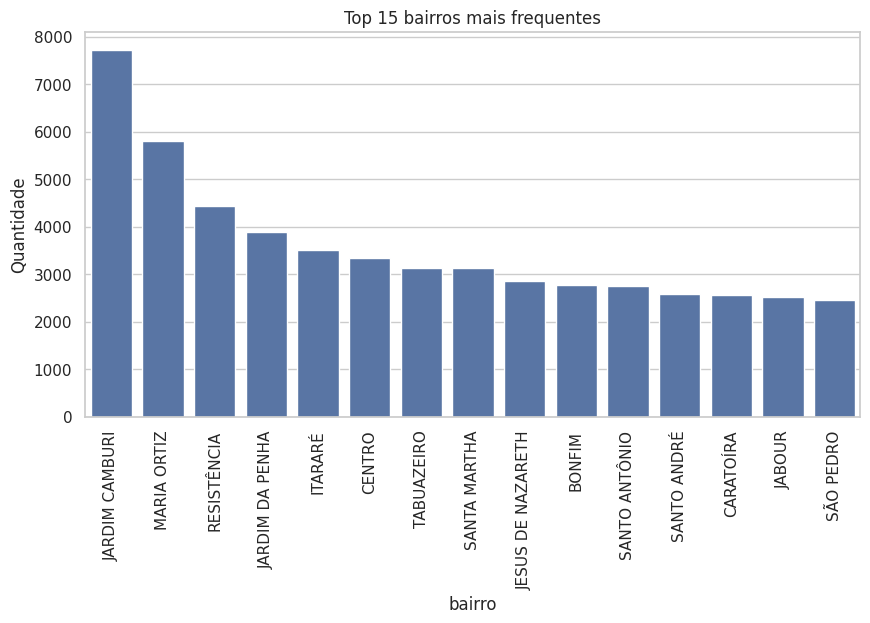

In [179]:
def plotar_barras_frequencia(dataframe, coluna, titulo, top_n=None, rotacao=0):
    dados_plot = dataframe[coluna].value_counts(dropna=False)

    if top_n is not None:
        dados_plot = dados_plot.head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=dados_plot.index.astype(str), y=dados_plot.values)
    plt.title(titulo)
    plt.xlabel(coluna)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=rotacao)
    plt.show()

plotar_barras_frequencia(df, "genero", "Distribuição por gênero")
plotar_barras_frequencia(df, "bolsa_familia", "Distribuição de bolsa_familia")
plotar_barras_frequencia(df, "hipertensao", "Distribuição de hipertensao")
plotar_barras_frequencia(df, "diabetes", "Distribuição de diabetes")
plotar_barras_frequencia(df, "alcoolismo", "Distribuição de alcoolismo")
plotar_barras_frequencia(df, "deficiencia", "Distribuição de deficiencia")
plotar_barras_frequencia(df, "sms_recebido", "Distribuição de sms_recebido")
plotar_barras_frequencia(df, "bairro", "Top 15 bairros mais frequentes", top_n=15, rotacao=90)

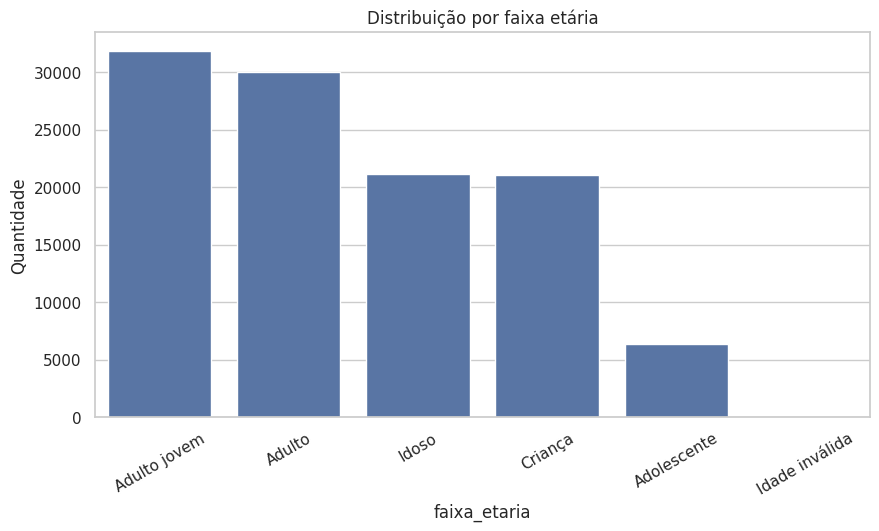

In [180]:
def criar_faixa_etaria(idade):
    if pd.isna(idade):
        return "Desconhecida"
    if idade < 0:
        return "Idade inválida"
    if idade <= 12:
        return "Criança"
    if idade <= 17:
        return "Adolescente"
    if idade <= 39:
        return "Adulto jovem"
    if idade <= 59:
        return "Adulto"
    return "Idoso"

df["faixa_etaria"] = df["idade"].apply(criar_faixa_etaria)

plotar_barras_frequencia(df, "faixa_etaria", "Distribuição por faixa etária", rotacao=30)

## 6.9 Análise temporal dos agendamentos

O dataset contém atributos temporais relacionados ao agendamento e à data da consulta. Esses campos são particularmente importantes neste problema, pois permitem investigar o intervalo entre o agendamento e o atendimento, além de possibilitar análises como dia da semana da consulta e tempo de espera.

Minha expectativa é que esse componente temporal seja um dos pontos mais relevantes para entender o comportamento de não comparecimento.

In [181]:
df["data_consulta_dia"] = df["data_consulta"].dt.date
df["dia_semana_consulta"] = df["data_consulta"].dt.day_name()
df["dia_semana_agendamento"] = df["data_agendamento"].dt.day_name()

df["dias_espera"] = (
    pd.to_datetime(df["data_consulta"].dt.date) - pd.to_datetime(df["data_agendamento"].dt.date)
).dt.days

display(df[["data_agendamento", "data_consulta", "dia_semana_consulta", "dias_espera"]].head())

,data_agendamento,data_consulta,dia_semana_consulta,dias_espera
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,Friday,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,Friday,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,Friday,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,Friday,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,Friday,0


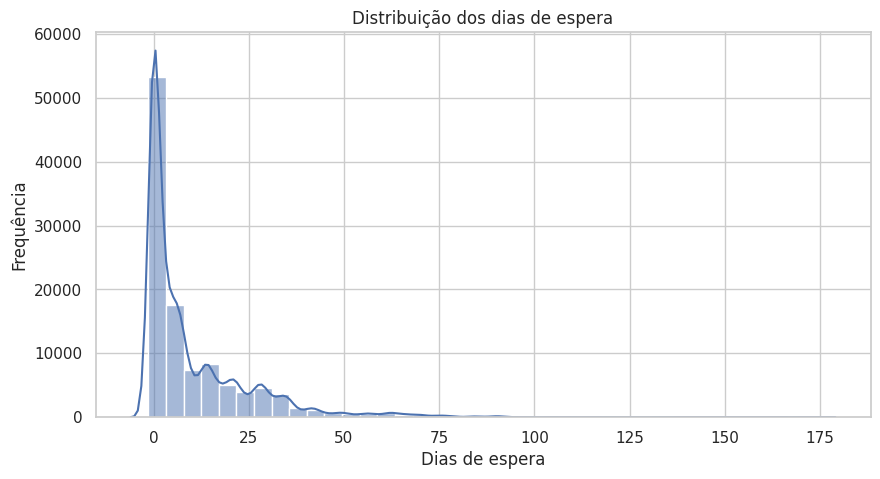

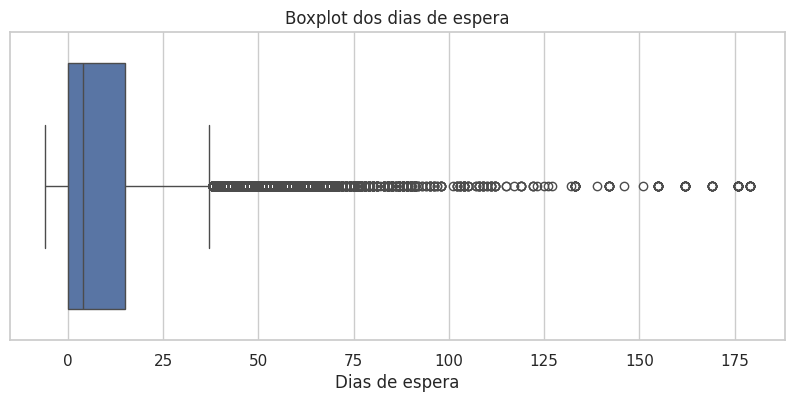

Resumo dos dias de espera:


,dias_espera
count,110527.00
mean,10.18
std,15.25
min,-6.00
25%,0.00
50%,4.00
75%,15.00
max,179.00


Registros com dias de espera negativos:


,id_paciente,id_consulta,genero,data_agendamento,data_consulta,idade,bairro,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou,faixa_etaria,data_consulta_dia,dia_semana_consulta,dia_semana_agendamento,dias_espera
27033,7839272661752.00,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,1,Adulto jovem,2016-05-09,Monday,Tuesday,-1
55226,7896293967868.00,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,1,Adulto jovem,2016-05-17,Tuesday,Wednesday,-1
64175,24252258389979.00,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,1,Adulto jovem,2016-05-04,Wednesday,Thursday,-1
71533,998231581612122.00,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,1,Idoso,2016-05-05,Thursday,Wednesday,-6
72362,3787481966821.00,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,1,Criança,2016-05-03,Tuesday,Wednesday,-1


In [182]:
plt.figure(figsize=(10, 5))
sns.histplot(df["dias_espera"], bins=40, kde=True)
plt.title("Distribuição dos dias de espera")
plt.xlabel("Dias de espera")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["dias_espera"])
plt.title("Boxplot dos dias de espera")
plt.xlabel("Dias de espera")
plt.show()

print("Resumo dos dias de espera:")
display(df["dias_espera"].describe())

print("Registros com dias de espera negativos:")
display(df[df["dias_espera"] < 0].head())

,dia_semana_consulta,faltou,faltou_percentual
0,Monday,0.21,20.65
1,Tuesday,0.20,20.09
2,Wednesday,0.20,19.69
3,Thursday,0.19,19.35
4,Friday,0.21,21.23
5,Saturday,0.23,23.08


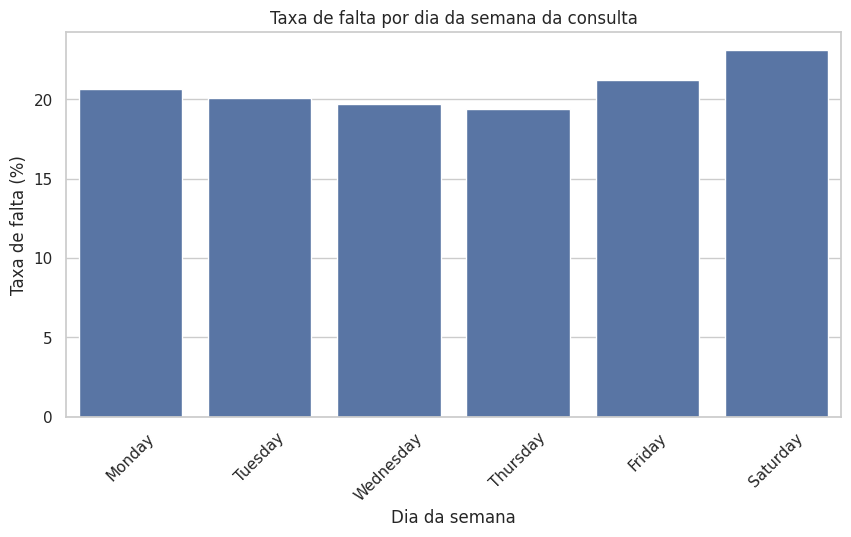

In [183]:
ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

taxa_falta_dia_semana = (
    df.groupby("dia_semana_consulta")["faltou"]
    .mean()
    .reindex(ordem_dias)
    .dropna()
    .reset_index()
)
taxa_falta_dia_semana["faltou_percentual"] = taxa_falta_dia_semana["faltou"] * 100

display(taxa_falta_dia_semana)

plt.figure(figsize=(10, 5))
sns.barplot(data=taxa_falta_dia_semana, x="dia_semana_consulta", y="faltou_percentual")
plt.title("Taxa de falta por dia da semana da consulta")
plt.xlabel("Dia da semana")
plt.ylabel("Taxa de falta (%)")
plt.xticks(rotation=45)
plt.show()

## 6.10 Relação entre atributos e o não comparecimento

Nesta subseção, exploro a relação entre diferentes atributos e a variável alvo. O objetivo é verificar, por meio de visualizações e comparações, se alguns grupos parecem apresentar taxas maiores ou menores de ausência.

Entre os atributos investigados, destacam-se sexo, idade, bairro, recebimento de SMS, condições de saúde e tempo de espera entre agendamento e consulta.

,genero,faltou,faltou_percentual
0,F,0.20,20.31
1,M,0.20,19.97


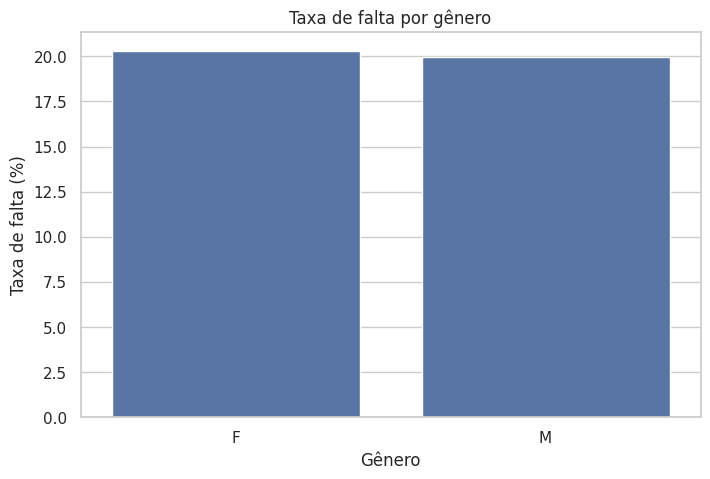

In [184]:
taxa_falta_genero = (
    df.groupby("genero")["faltou"]
    .mean()
    .reset_index()
    .sort_values(by="faltou", ascending=False)
)
taxa_falta_genero["faltou_percentual"] = taxa_falta_genero["faltou"] * 100

display(taxa_falta_genero)

plt.figure(figsize=(8, 5))
sns.barplot(data=taxa_falta_genero, x="genero", y="faltou_percentual")
plt.title("Taxa de falta por gênero")
plt.xlabel("Gênero")
plt.ylabel("Taxa de falta (%)")
plt.show()

,sms_recebido,faltou,faltou_percentual
1,1,0.28,27.57
0,0,0.17,16.70


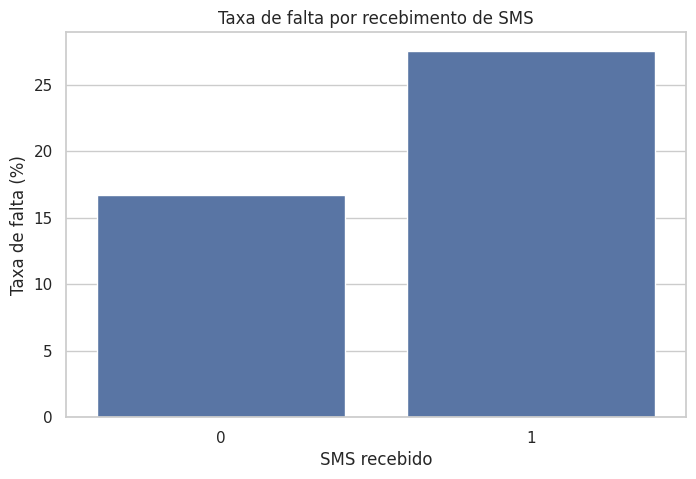

In [185]:
taxa_falta_sms = (
    df.groupby("sms_recebido")["faltou"]
    .mean()
    .reset_index()
    .sort_values(by="faltou", ascending=False)
)
taxa_falta_sms["faltou_percentual"] = taxa_falta_sms["faltou"] * 100

display(taxa_falta_sms)

plt.figure(figsize=(8, 5))
sns.barplot(data=taxa_falta_sms, x="sms_recebido", y="faltou_percentual")
plt.title("Taxa de falta por recebimento de SMS")
plt.xlabel("SMS recebido")
plt.ylabel("Taxa de falta (%)")
plt.show()

,hipertensao,faltou,faltou_percentual
0,0,0.21,20.90
1,1,0.17,17.30


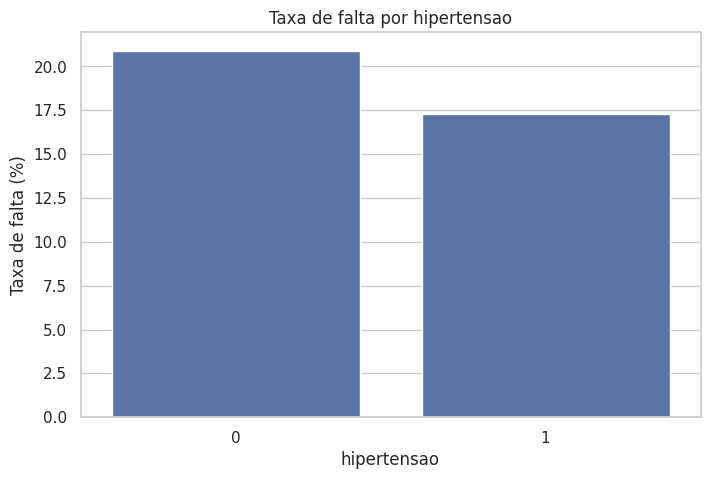

,diabetes,faltou,faltou_percentual
0,0,0.20,20.36
1,1,0.18,18.00


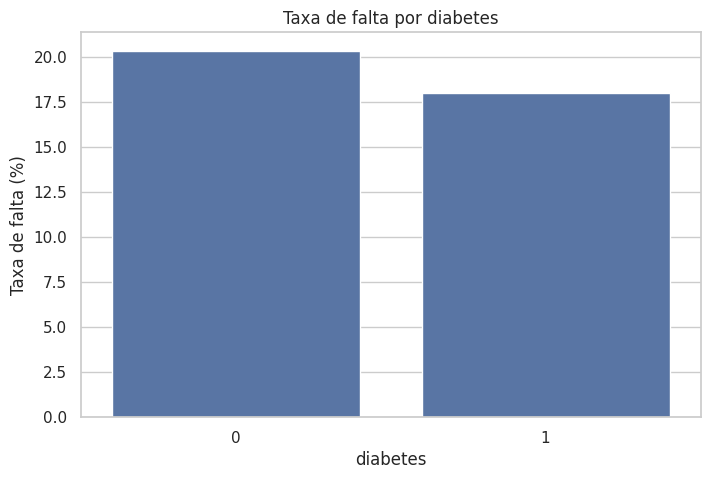

,alcoolismo,faltou,faltou_percentual
0,0,0.20,20.19
1,1,0.20,20.15


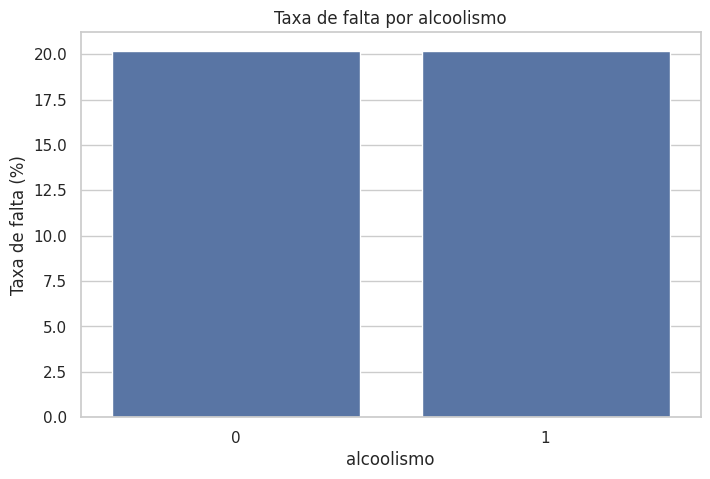

,deficiencia,faltou,faltou_percentual
4,4,0.33,33.33
3,3,0.23,23.08
0,0,0.20,20.24
2,2,0.20,20.22
1,1,0.18,17.92


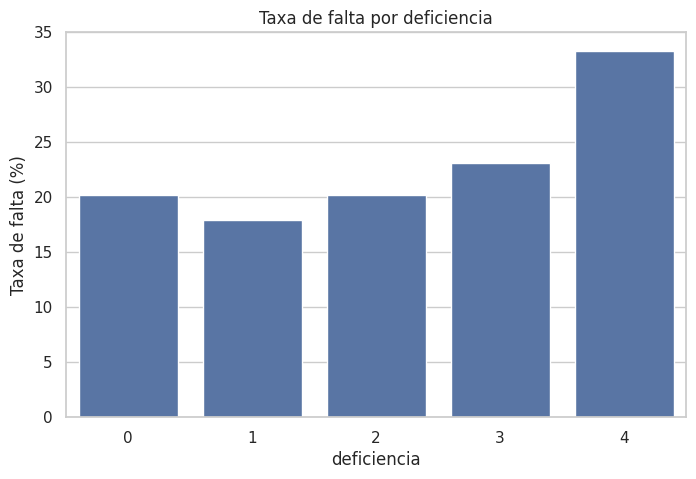

In [186]:
colunas_saude = ["hipertensao", "diabetes", "alcoolismo", "deficiencia"]

for coluna in colunas_saude:
    taxa = (
        df.groupby(coluna)["faltou"]
        .mean()
        .reset_index()
        .sort_values(by="faltou", ascending=False)
    )
    taxa["faltou_percentual"] = taxa["faltou"] * 100

    display(taxa)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=taxa, x=coluna, y="faltou_percentual")
    plt.title(f"Taxa de falta por {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Taxa de falta (%)")
    plt.show()

,faixa_etaria,faltou,faltou_percentual
0,Criança,0.20,20.47
1,Adolescente,0.27,26.64
2,Adulto jovem,0.23,23.27
3,Adulto,0.19,18.81
4,Idoso,0.15,15.31
5,Idade inválida,0.00,0.00


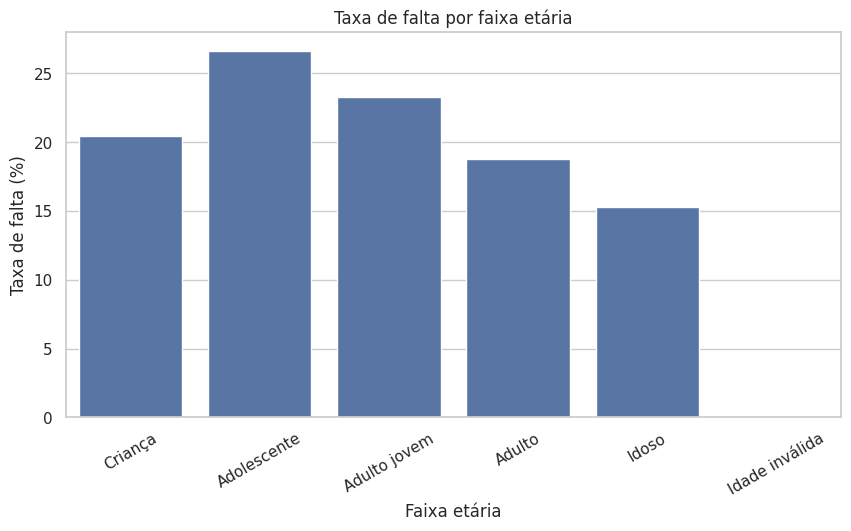

In [187]:
ordem_faixas = ["Criança", "Adolescente", "Adulto jovem", "Adulto", "Idoso", "Idade inválida", "Desconhecida"]

taxa_falta_faixa_etaria = (
    df.groupby("faixa_etaria")["faltou"]
    .mean()
    .reindex(ordem_faixas)
    .dropna()
    .reset_index()
)
taxa_falta_faixa_etaria["faltou_percentual"] = taxa_falta_faixa_etaria["faltou"] * 100

display(taxa_falta_faixa_etaria)

plt.figure(figsize=(10, 5))
sns.barplot(data=taxa_falta_faixa_etaria, x="faixa_etaria", y="faltou_percentual")
plt.title("Taxa de falta por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de falta (%)")
plt.xticks(rotation=30)
plt.show()

,bairro,faltou,faltou_percentual
3,ITARARÉ,0.26,26.27
7,JESUS DE NAZARETH,0.24,24.40
1,CARATOÍRA,0.23,23.04
2,CENTRO,0.21,21.09
13,SÃO PEDRO,0.21,21.04
8,MARIA ORTIZ,0.21,21.00
9,RESISTÊNCIA,0.20,20.45
0,BONFIM,0.20,19.83
11,SANTO ANDRÉ,0.20,19.76
5,JARDIM CAMBURI,0.19,18.98


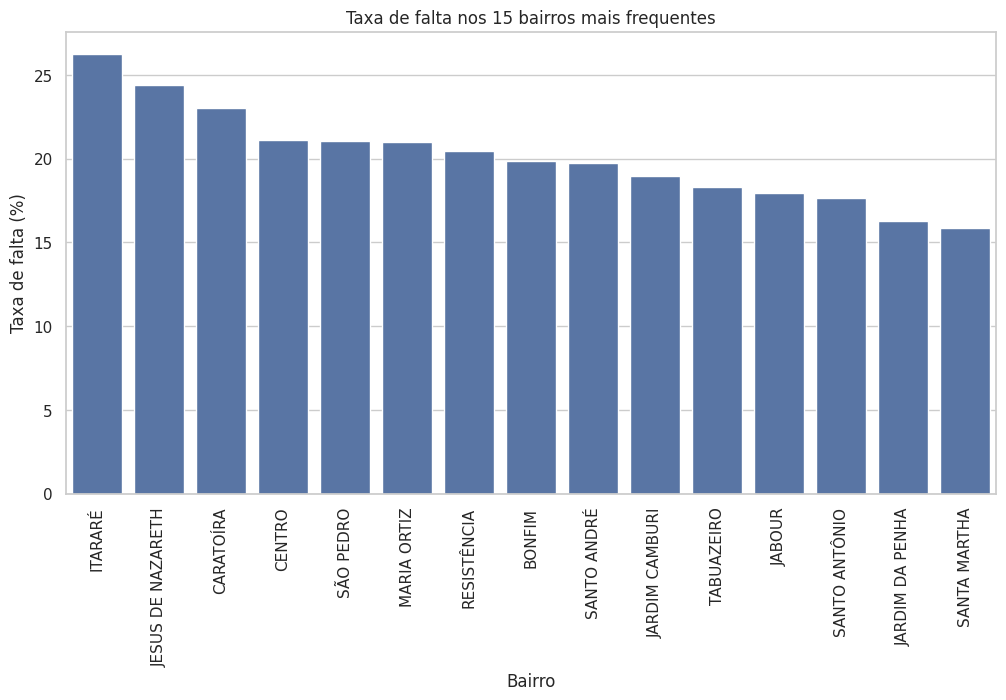

In [188]:
top_bairros = df["bairro"].value_counts().head(15).index.tolist()

df_top_bairros = df[df["bairro"].isin(top_bairros)].copy()

taxa_falta_bairro = (
    df_top_bairros.groupby("bairro")["faltou"]
    .mean()
    .reset_index()
    .sort_values(by="faltou", ascending=False)
)
taxa_falta_bairro["faltou_percentual"] = taxa_falta_bairro["faltou"] * 100

display(taxa_falta_bairro)

plt.figure(figsize=(12, 6))
sns.barplot(data=taxa_falta_bairro, x="bairro", y="faltou_percentual")
plt.title("Taxa de falta nos 15 bairros mais frequentes")
plt.xlabel("Bairro")
plt.ylabel("Taxa de falta (%)")
plt.xticks(rotation=90)
plt.show()

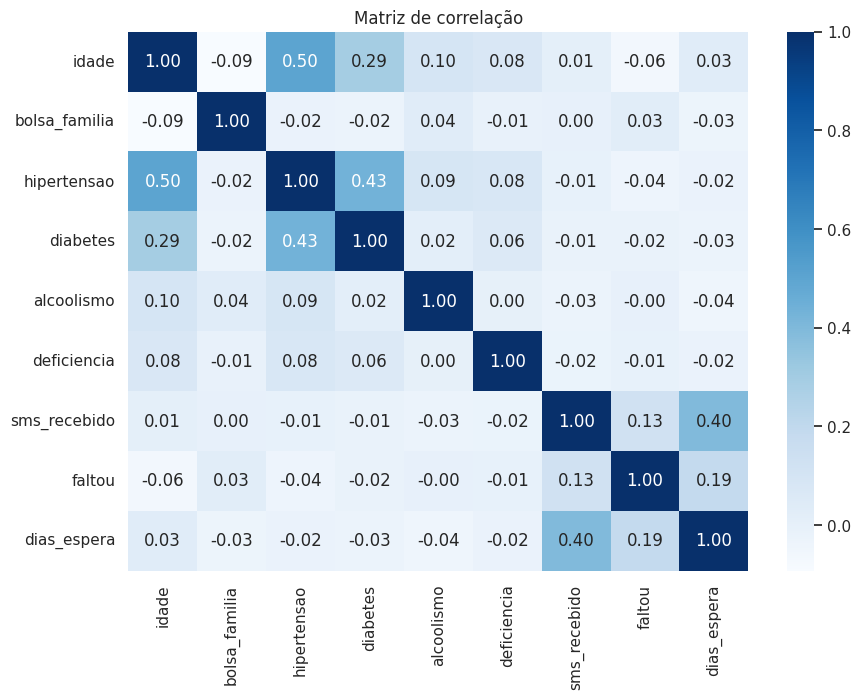

,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou,dias_espera
idade,1.00,-0.09,0.50,0.29,0.10,0.08,0.01,-0.06,0.03
bolsa_familia,-0.09,1.00,-0.02,-0.02,0.04,-0.01,0.00,0.03,-0.03
hipertensao,0.50,-0.02,1.00,0.43,0.09,0.08,-0.01,-0.04,-0.02
diabetes,0.29,-0.02,0.43,1.00,0.02,0.06,-0.01,-0.02,-0.03
alcoolismo,0.10,0.04,0.09,0.02,1.00,0.00,-0.03,-0.00,-0.04
deficiencia,0.08,-0.01,0.08,0.06,0.00,1.00,-0.02,-0.01,-0.02
sms_recebido,0.01,0.00,-0.01,-0.01,-0.03,-0.02,1.00,0.13,0.40
faltou,-0.06,0.03,-0.04,-0.02,-0.00,-0.01,0.13,1.00,0.19
dias_espera,0.03,-0.03,-0.02,-0.03,-0.04,-0.02,0.40,0.19,1.00


In [189]:
colunas_correlacao = ["idade", "bolsa_familia", "hipertensao", "diabetes", "alcoolismo", "deficiencia", "sms_recebido", "faltou", "dias_espera"]

matriz_correlacao = df[colunas_correlacao].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlação")
plt.show()

display(matriz_correlacao)

## 6.11 Síntese da análise exploratória

Com base na análise exploratória realizada até aqui, já é possível identificar alguns pontos importantes sobre a base, como padrões de distribuição, potenciais inconsistências, possíveis outliers e variáveis que parecem ter relação com o não comparecimento.

Esses achados serão utilizados como base para a etapa de pré-processamento, em que aplicarei transformações e tratamentos justificados com o objetivo de tornar os dados mais consistentes, interpretáveis e adequados para uso analítico posterior.

In [190]:
print("Resumo da EDA:")
print(f"- Total de registros: {len(df)}")
print(f"- Total de colunas: {len(df.columns)}")
print(f"- Total de valores ausentes: {df.isna().sum().sum()}")
print(f"- Duplicados completos: {df.duplicated().sum()}")
print(f"- Idades negativas: {(df['idade'] < 0).sum()}")
print(f"- Registros com dias de espera negativos: {(df['dias_espera'] < 0).sum()}")
print(f"- Taxa geral de falta: {df['faltou'].mean() * 100:.2f}%")

Resumo da EDA:
- Total de registros: 110527
- Total de colunas: 19
- Total de valores ausentes: 0
- Duplicados completos: 0
- Idades negativas: 1
- Registros com dias de espera negativos: 5
- Taxa geral de falta: 20.19%


# 7. Pré-processamento de dados

Após compreender melhor os dados por meio da análise exploratória, inicio agora a etapa de pré-processamento. O objetivo desta fase é tratar inconsistências, corrigir tipos, lidar com valores problemáticos e construir versões mais adequadas da base para uso analítico e, eventualmente, para modelagem futura.

As operações realizadas a seguir são justificadas com base nos padrões observados na etapa anterior.

In [191]:
df_limpo = df.copy()
df_tratado = df.copy()

## 7.1 Limpeza inicial da base

Nesta etapa, realizo ajustes básicos na estrutura do dataset, como padronização de nomes de colunas, correção de tipos de dados e organização geral da base. Essa limpeza inicial é importante para facilitar as análises seguintes e reduzir a chance de erros no restante do notebook.

In [192]:
print("Shape antes da limpeza:", df_tratado.shape)

df_tratado = df_tratado.drop_duplicates()

print("Shape após remoção de duplicados completos:", df_tratado.shape)

Shape antes da limpeza: (110527, 19)
Shape após remoção de duplicados completos: (110527, 19)


## 7.2 Tratamento de inconsistências

Aqui, trato possíveis inconsistências identificadas durante a análise exploratória, como valores incompatíveis com o domínio do problema, registros suspeitos ou problemas relacionados às variáveis temporais.

As decisões tomadas nesta etapa são justificadas caso a caso, buscando manter o máximo possível de coerência com o contexto do problema.

In [193]:
quantidade_idade_negativa = (df_tratado["idade"] < 0).sum()
print("Quantidade de registros com idade negativa:", quantidade_idade_negativa)

df_tratado = df_tratado[df_tratado["idade"] >= 0].copy()

print("Shape após remoção de idades negativas:", df_tratado.shape)

Quantidade de registros com idade negativa: 1
Shape após remoção de idades negativas: (110526, 19)


In [194]:
quantidade_espera_negativa = (df_tratado["dias_espera"] < 0).sum()
print("Quantidade de registros com dias de espera negativos:", quantidade_espera_negativa)

df_tratado = df_tratado[df_tratado["dias_espera"] >= 0].copy()

print("Shape após remoção de dias de espera negativos:", df_tratado.shape)

Quantidade de registros com dias de espera negativos: 5
Shape após remoção de dias de espera negativos: (110521, 19)


## 7.3 Tratamento de valores faltantes

Caso sejam identificados valores ausentes, nesta etapa avalio a melhor estratégia para tratá-los. Dependendo da quantidade de registros afetados e da importância do atributo, o tratamento pode envolver remoção, imputação ou manutenção controlada.

A escolha do tratamento será sempre justificada com base na natureza do dado e no impacto esperado sobre a análise.

In [195]:
print("Valores faltantes antes do tratamento:")
display(df_tratado.isna().sum())

colunas_essenciais = ["genero", "data_agendamento", "data_consulta", "idade", "bairro", "faltou", "dias_espera"]

df_tratado = df_tratado.dropna(subset=colunas_essenciais).copy()

print("Valores faltantes depois do tratamento:")
display(df_tratado.isna().sum())

print("Shape após tratamento de faltantes:", df_tratado.shape)

Valores faltantes antes do tratamento:


,0
id_paciente,0
id_consulta,0
genero,0
data_agendamento,0
data_consulta,0
idade,0
bairro,0
bolsa_familia,0
hipertensao,0
diabetes,0


Valores faltantes depois do tratamento:


,0
id_paciente,0
id_consulta,0
genero,0
data_agendamento,0
data_consulta,0
idade,0
bairro,0
bolsa_familia,0
hipertensao,0
diabetes,0


Shape após tratamento de faltantes: (110521, 19)


## 7.4 Engenharia de atributos

Além da limpeza da base, também podem ser criados novos atributos a partir de colunas já existentes. Neste problema, atributos derivados do componente temporal, como o tempo de espera entre agendamento e consulta, podem ser particularmente úteis para enriquecer a análise.

Esse tipo de transformação contribui para tornar padrões mais visíveis e facilitar interpretações futuras.

In [196]:
df_tratado["faixa_etaria"] = df_tratado["idade"].apply(criar_faixa_etaria)

def criar_faixa_espera(dias):
    if dias <= 0:
        return "Mesmo dia"
    if dias <= 3:
        return "1 a 3 dias"
    if dias <= 7:
        return "4 a 7 dias"
    if dias <= 14:
        return "8 a 14 dias"
    if dias <= 30:
        return "15 a 30 dias"
    return "Mais de 30 dias"

df_tratado["faixa_espera"] = df_tratado["dias_espera"].apply(criar_faixa_espera)

display(df_tratado[["idade", "faixa_etaria", "dias_espera", "faixa_espera"]].head())

,idade,faixa_etaria,dias_espera,faixa_espera
0,62,Idoso,0,Mesmo dia
1,56,Adulto,0,Mesmo dia
2,62,Idoso,0,Mesmo dia
3,8,Criança,0,Mesmo dia
4,56,Adulto,0,Mesmo dia


## 7.5 Transformações e preparação dos dados

Nesta etapa, aplico transformações que julgo adequadas para a natureza do dataset e para os objetivos deste MVP. Dependendo do caso, essas transformações podem incluir discretização, recodificação de categorias, separação entre variáveis explicativas e alvo, e preparação de versões da base para uso futuro em modelagem.

In [197]:
df_modelagem = df_tratado.copy()

colunas_remover_modelagem = ["id_paciente", "id_consulta", "data_agendamento", "data_consulta", "data_consulta_dia"]
df_modelagem.drop(columns=colunas_remover_modelagem, inplace=True, errors="ignore")

print("Shape da base de modelagem:", df_modelagem.shape)
display(df_modelagem.head())

Shape da base de modelagem: (110521, 15)


,genero,idade,bairro,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou,faixa_etaria,dia_semana_consulta,dia_semana_agendamento,dias_espera,faixa_espera
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,Idoso,Friday,Friday,0,Mesmo dia
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,Adulto,Friday,Friday,0,Mesmo dia
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,Idoso,Friday,Friday,0,Mesmo dia
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,Criança,Friday,Friday,0,Mesmo dia
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,Adulto,Friday,Friday,0,Mesmo dia


In [198]:
colunas_categoricas_modelagem = ["genero", "bairro", "dia_semana_consulta", "dia_semana_agendamento", "faixa_etaria", "faixa_espera"]

df_modelagem = pd.get_dummies(
    df_modelagem,
    columns=colunas_categoricas_modelagem,
    drop_first=True
)

print("Shape após one-hot encoding:", df_modelagem.shape)
display(df_modelagem.head())

Shape após one-hot encoding: (110521, 109)


,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,faltou,dias_espera,genero_M,bairro_ANDORINHAS,bairro_ANTÔNIO HONÓRIO,bairro_ARIOVALDO FAVALESSA,bairro_BARRO VERMELHO,bairro_BELA VISTA,bairro_BENTO FERREIRA,bairro_BOA VISTA,bairro_BONFIM,bairro_CARATOÍRA,bairro_CENTRO,bairro_COMDUSA,bairro_CONQUISTA,bairro_CONSOLAÇÃO,bairro_CRUZAMENTO,bairro_DA PENHA,bairro_DE LOURDES,bairro_DO CABRAL,bairro_DO MOSCOSO,bairro_DO QUADRO,bairro_ENSEADA DO SUÁ,bairro_ESTRELINHA,bairro_FONTE GRANDE,bairro_FORTE SÃO JOÃO,bairro_FRADINHOS,bairro_GOIABEIRAS,bairro_GRANDE VITÓRIA,bairro_GURIGICA,bairro_HORTO,bairro_ILHA DAS CAIEIRAS,bairro_ILHA DE SANTA MARIA,bairro_ILHA DO BOI,bairro_ILHA DO FRADE,bairro_ILHA DO PRÍNCIPE,bairro_ILHAS OCEÂNICAS DE TRINDADE,bairro_INHANGUETÁ,bairro_ITARARÉ,bairro_JABOUR,bairro_JARDIM CAMBURI,bairro_JARDIM DA PENHA,bairro_JESUS DE NAZARETH,bairro_JOANA D´ARC,bairro_JUCUTUQUARA,bairro_MARIA ORTIZ,bairro_MARUÍPE,bairro_MATA DA PRAIA,bairro_MONTE BELO,bairro_MORADA DE CAMBURI,bairro_MÁRIO CYPRESTE,bairro_NAZARETH,bairro_NOVA PALESTINA,bairro_PARQUE INDUSTRIAL,bairro_PARQUE MOSCOSO,bairro_PIEDADE,bairro_PONTAL DE CAMBURI,bairro_PRAIA DO CANTO,bairro_PRAIA DO SUÁ,bairro_REDENÇÃO,bairro_REPÚBLICA,bairro_RESISTÊNCIA,bairro_ROMÃO,bairro_SANTA CECÍLIA,bairro_SANTA CLARA,bairro_SANTA HELENA,bairro_SANTA LUÍZA,bairro_SANTA LÚCIA,bairro_SANTA MARTHA,bairro_SANTA TEREZA,bairro_SANTO ANDRÉ,bairro_SANTO ANTÔNIO,bairro_SANTOS DUMONT,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM,dia_semana_consulta_Monday,dia_semana_consulta_Saturday,dia_semana_consulta_Thursday,dia_semana_consulta_Tuesday,dia_semana_consulta_Wednesday,dia_semana_agendamento_Monday,dia_semana_agendamento_Saturday,dia_semana_agendamento_Thursday,dia_semana_agendamento_Tuesday,dia_semana_agendamento_Wednesday,faixa_etaria_Adulto,faixa_etaria_Adulto jovem,faixa_etaria_Criança,faixa_etaria_Idoso,faixa_espera_15 a 30 dias,faixa_espera_4 a 7 dias,faixa_espera_8 a 14 dias,faixa_espera_Mais de 30 dias,faixa_espera_Mesmo dia
0,62,0,1,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
1,56,0,0,0,0,0,0,0,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
2,62,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

## 7.6 Separação entre variáveis explicativas e variável alvo

Nesta subseção, separo a variável alvo das variáveis explicativas. Embora a sprint atual não exija o treinamento de modelos, essa organização deixa a base preparada para etapas futuras do projeto e contribui para uma estrutura mais clara do notebook.

In [199]:
X = df_modelagem.drop(columns=["faltou"])
y = df_modelagem["faltou"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (110521, 108)
Shape de y: (110521,)


## 7.7 Divisão entre treino e teste

Como preparação adicional da base, realizo a divisão entre conjuntos de treino e teste. Essa etapa é típica em problemas supervisionados de classificação e contribui para deixar o dataset pronto para possíveis desdobramentos em sprints futuras ou em análises complementares.

In [200]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (88416, 108)
X_teste: (22105, 108)
y_treino: (88416,)
y_teste: (22105,)


In [201]:
colunas_numericas_modelagem = ["idade", "dias_espera"]

padronizador = StandardScaler()
X_treino_padronizado = X_treino.copy()
X_teste_padronizado = X_teste.copy()

X_treino_padronizado[colunas_numericas_modelagem] = padronizador.fit_transform(X_treino[colunas_numericas_modelagem])
X_teste_padronizado[colunas_numericas_modelagem] = padronizador.transform(X_teste[colunas_numericas_modelagem])

normalizador = MinMaxScaler()
X_treino_normalizado = X_treino.copy()
X_teste_normalizado = X_teste.copy()

X_treino_normalizado[colunas_numericas_modelagem] = normalizador.fit_transform(X_treino[colunas_numericas_modelagem])
X_teste_normalizado[colunas_numericas_modelagem] = normalizador.transform(X_teste[colunas_numericas_modelagem])

print("Exemplo de base padronizada:")
display(X_treino_padronizado.head())

print("Exemplo de base normalizada:")
display(X_treino_normalizado.head())

Exemplo de base padronizada:


,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,dias_espera,genero_M,bairro_ANDORINHAS,bairro_ANTÔNIO HONÓRIO,bairro_ARIOVALDO FAVALESSA,bairro_BARRO VERMELHO,bairro_BELA VISTA,bairro_BENTO FERREIRA,bairro_BOA VISTA,bairro_BONFIM,bairro_CARATOÍRA,bairro_CENTRO,bairro_COMDUSA,bairro_CONQUISTA,bairro_CONSOLAÇÃO,bairro_CRUZAMENTO,bairro_DA PENHA,bairro_DE LOURDES,bairro_DO CABRAL,bairro_DO MOSCOSO,bairro_DO QUADRO,bairro_ENSEADA DO SUÁ,bairro_ESTRELINHA,bairro_FONTE GRANDE,bairro_FORTE SÃO JOÃO,bairro_FRADINHOS,bairro_GOIABEIRAS,bairro_GRANDE VITÓRIA,bairro_GURIGICA,bairro_HORTO,bairro_ILHA DAS CAIEIRAS,bairro_ILHA DE SANTA MARIA,bairro_ILHA DO BOI,bairro_ILHA DO FRADE,bairro_ILHA DO PRÍNCIPE,bairro_ILHAS OCEÂNICAS DE TRINDADE,bairro_INHANGUETÁ,bairro_ITARARÉ,bairro_JABOUR,bairro_JARDIM CAMBURI,bairro_JARDIM DA PENHA,bairro_JESUS DE NAZARETH,bairro_JOANA D´ARC,bairro_JUCUTUQUARA,bairro_MARIA ORTIZ,bairro_MARUÍPE,bairro_MATA DA PRAIA,bairro_MONTE BELO,bairro_MORADA DE CAMBURI,bairro_MÁRIO CYPRESTE,bairro_NAZARETH,bairro_NOVA PALESTINA,bairro_PARQUE INDUSTRIAL,bairro_PARQUE MOSCOSO,bairro_PIEDADE,bairro_PONTAL DE CAMBURI,bairro_PRAIA DO CANTO,bairro_PRAIA DO SUÁ,bairro_REDENÇÃO,bairro_REPÚBLICA,bairro_RESISTÊNCIA,bairro_ROMÃO,bairro_SANTA CECÍLIA,bairro_SANTA CLARA,bairro_SANTA HELENA,bairro_SANTA LUÍZA,bairro_SANTA LÚCIA,bairro_SANTA MARTHA,bairro_SANTA TEREZA,bairro_SANTO ANDRÉ,bairro_SANTO ANTÔNIO,bairro_SANTOS DUMONT,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM,dia_semana_consulta_Monday,dia_semana_consulta_Saturday,dia_semana_consulta_Thursday,dia_semana_consulta_Tuesday,dia_semana_consulta_Wednesday,dia_semana_agendamento_Monday,dia_semana_agendamento_Saturday,dia_semana_agendamento_Thursday,dia_semana_agendamento_Tuesday,dia_semana_agendamento_Wednesday,faixa_etaria_Adulto,faixa_etaria_Adulto jovem,faixa_etaria_Criança,faixa_etaria_Idoso,faixa_espera_15 a 30 dias,faixa_espera_4 a 7 dias,faixa_espera_8 a 14 dias,faixa_espera_Mais de 30 dias,faixa_espera_Mesmo dia
46757,1.60,0,1,1,0,0,0,1.62,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
58860,1.04,0,0,0,0,0,0,-0.60,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
25707,-0.70,0,0,0,0,0,0,0.25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,

Exemplo de base normalizada:


,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,dias_espera,genero_M,bairro_ANDORINHAS,bairro_ANTÔNIO HONÓRIO,bairro_ARIOVALDO FAVALESSA,bairro_BARRO VERMELHO,bairro_BELA VISTA,bairro_BENTO FERREIRA,bairro_BOA VISTA,bairro_BONFIM,bairro_CARATOÍRA,bairro_CENTRO,bairro_COMDUSA,bairro_CONQUISTA,bairro_CONSOLAÇÃO,bairro_CRUZAMENTO,bairro_DA PENHA,bairro_DE LOURDES,bairro_DO CABRAL,bairro_DO MOSCOSO,bairro_DO QUADRO,bairro_ENSEADA DO SUÁ,bairro_ESTRELINHA,bairro_FONTE GRANDE,bairro_FORTE SÃO JOÃO,bairro_FRADINHOS,bairro_GOIABEIRAS,bairro_GRANDE VITÓRIA,bairro_GURIGICA,bairro_HORTO,bairro_ILHA DAS CAIEIRAS,bairro_ILHA DE SANTA MARIA,bairro_ILHA DO BOI,bairro_ILHA DO FRADE,bairro_ILHA DO PRÍNCIPE,bairro_ILHAS OCEÂNICAS DE TRINDADE,bairro_INHANGUETÁ,bairro_ITARARÉ,bairro_JABOUR,bairro_JARDIM CAMBURI,bairro_JARDIM DA PENHA,bairro_JESUS DE NAZARETH,bairro_JOANA D´ARC,bairro_JUCUTUQUARA,bairro_MARIA ORTIZ,bairro_MARUÍPE,bairro_MATA DA PRAIA,bairro_MONTE BELO,bairro_MORADA DE CAMBURI,bairro_MÁRIO CYPRESTE,bairro_NAZARETH,bairro_NOVA PALESTINA,bairro_PARQUE INDUSTRIAL,bairro_PARQUE MOSCOSO,bairro_PIEDADE,bairro_PONTAL DE CAMBURI,bairro_PRAIA DO CANTO,bairro_PRAIA DO SUÁ,bairro_REDENÇÃO,bairro_REPÚBLICA,bairro_RESISTÊNCIA,bairro_ROMÃO,bairro_SANTA CECÍLIA,bairro_SANTA CLARA,bairro_SANTA HELENA,bairro_SANTA LUÍZA,bairro_SANTA LÚCIA,bairro_SANTA MARTHA,bairro_SANTA TEREZA,bairro_SANTO ANDRÉ,bairro_SANTO ANTÔNIO,bairro_SANTOS DUMONT,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM,dia_semana_consulta_Monday,dia_semana_consulta_Saturday,dia_semana_consulta_Thursday,dia_semana_consulta_Tuesday,dia_semana_consulta_Wednesday,dia_semana_agendamento_Monday,dia_semana_agendamento_Saturday,dia_semana_agendamento_Thursday,dia_semana_agendamento_Tuesday,dia_semana_agendamento_Wednesday,faixa_etaria_Adulto,faixa_etaria_Adulto jovem,faixa_etaria_Criança,faixa_etaria_Idoso,faixa_espera_15 a 30 dias,faixa_espera_4 a 7 dias,faixa_espera_8 a 14 dias,faixa_espera_Mais de 30 dias,faixa_espera_Mesmo dia
46757,0.64,0,1,1,0,0,0,0.20,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
58860,0.53,0,0,0,0,0,0,0.01,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
25707,0.18,0,0,0,0,0,0,0.08,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,Fa

# 8. Reanálise após o pré-processamento

Depois de aplicar as operações de pré-processamento, retorno a alguns aspectos da análise exploratória para verificar como os dados se comportam na versão tratada da base.

Essa etapa é importante porque o pré-processamento pode revelar padrões que antes estavam escondidos, além de permitir uma visão mais consistente e limpa dos dados.

,faixa_espera,faltou,faltou_percentual
0,Mesmo dia,0.05,4.65
1,1 a 3 dias,0.23,22.89
2,4 a 7 dias,0.25,25.20
3,8 a 14 dias,0.30,30.47
4,15 a 30 dias,0.33,32.59
5,Mais de 30 dias,0.33,33.00


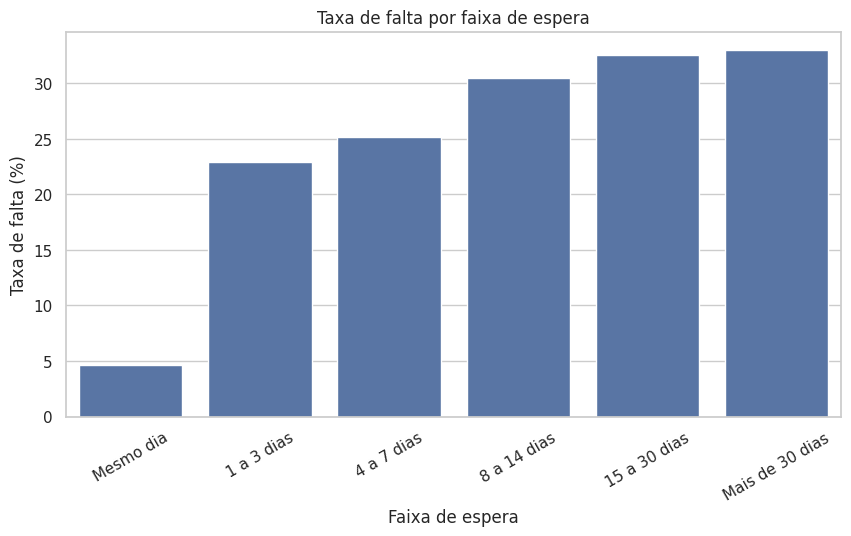

In [202]:
ordem_espera = ["Mesmo dia", "1 a 3 dias", "4 a 7 dias", "8 a 14 dias", "15 a 30 dias", "Mais de 30 dias"]

taxa_falta_faixa_espera = (
    df_tratado.groupby("faixa_espera")["faltou"]
    .mean()
    .reindex(ordem_espera)
    .dropna()
    .reset_index()
)
taxa_falta_faixa_espera["faltou_percentual"] = taxa_falta_faixa_espera["faltou"] * 100

display(taxa_falta_faixa_espera)

plt.figure(figsize=(10, 5))
sns.barplot(data=taxa_falta_faixa_espera, x="faixa_espera", y="faltou_percentual")
plt.title("Taxa de falta por faixa de espera")
plt.xlabel("Faixa de espera")
plt.ylabel("Taxa de falta (%)")
plt.xticks(rotation=30)
plt.show()

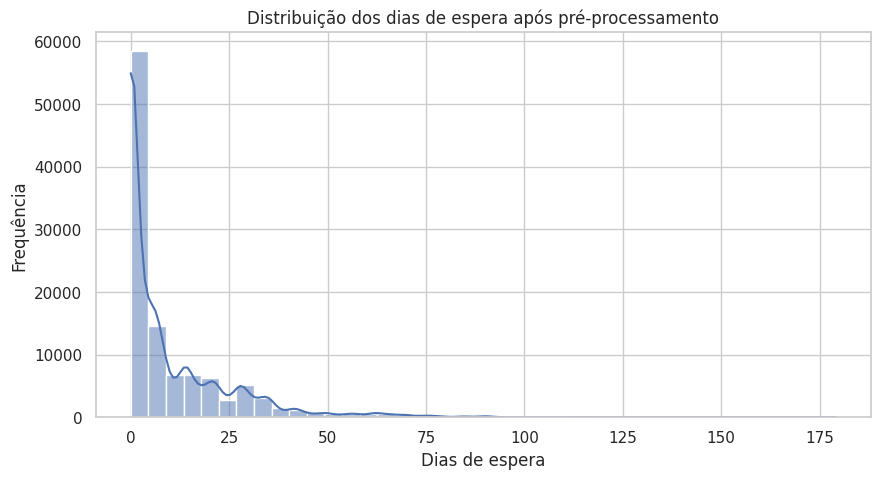

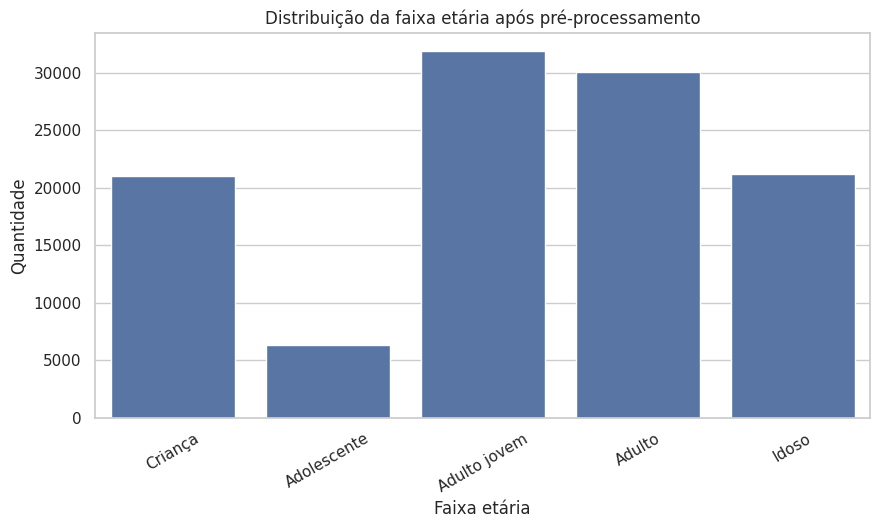

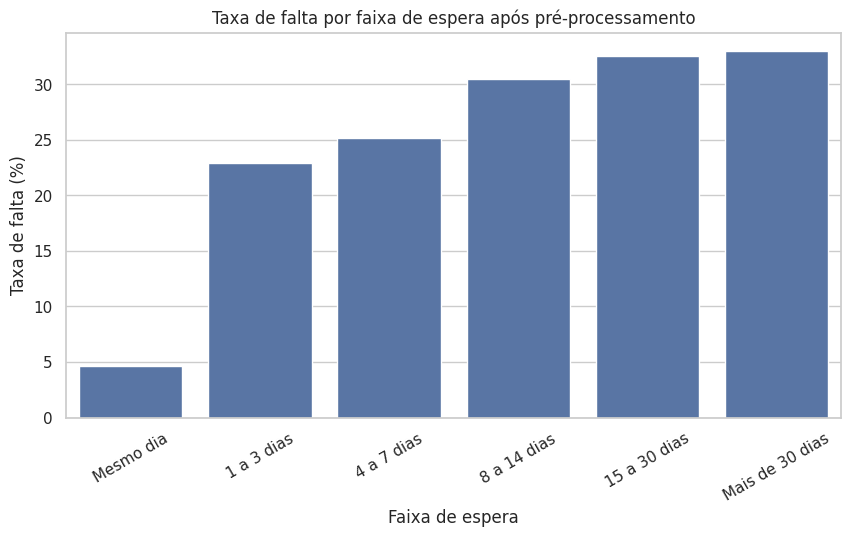

In [203]:
plt.figure(figsize=(10, 5))
sns.histplot(df_tratado["dias_espera"], bins=40, kde=True)
plt.title("Distribuição dos dias de espera após pré-processamento")
plt.xlabel("Dias de espera")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df_tratado, x="faixa_etaria", order=ordem_faixas[:-2])
plt.title("Distribuição da faixa etária após pré-processamento")
plt.xlabel("Faixa etária")
plt.ylabel("Quantidade")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=taxa_falta_faixa_espera, x="faixa_espera", y="faltou_percentual")
plt.title("Taxa de falta por faixa de espera após pré-processamento")
plt.xlabel("Faixa de espera")
plt.ylabel("Taxa de falta (%)")
plt.xticks(rotation=30)
plt.show()

# 9. Resposta às hipóteses iniciais

Com base na análise exploratória e nas transformações realizadas, retomo agora as hipóteses iniciais apresentadas no início do notebook.

O objetivo desta seção é avaliar se os dados parecem sustentar, refutar ou apenas sugerir parcialmente cada hipótese formulada.

In [204]:
print("Taxa geral de falta após tratamento:")
print(f"{df_tratado['faltou'].mean() * 100:.2f}%")

print("\nTaxa de falta por gênero:")
display(taxa_falta_genero)

print("\nTaxa de falta por SMS:")
display(taxa_falta_sms)

print("\nTaxa de falta por faixa etária:")
display(taxa_falta_faixa_etaria)

print("\nTaxa de falta por faixa de espera:")
display(taxa_falta_faixa_espera)

print("\nTop bairros por taxa de falta:")
display(taxa_falta_bairro.head(10))

Taxa geral de falta após tratamento:
20.19%

Taxa de falta por gênero:


,genero,faltou,faltou_percentual
0,F,0.20,20.31
1,M,0.20,19.97



Taxa de falta por SMS:


,sms_recebido,faltou,faltou_percentual
1,1,0.28,27.57
0,0,0.17,16.70



Taxa de falta por faixa etária:


,faixa_etaria,faltou,faltou_percentual
0,Criança,0.20,20.47
1,Adolescente,0.27,26.64
2,Adulto jovem,0.23,23.27
3,Adulto,0.19,18.81
4,Idoso,0.15,15.31
5,Idade inválida,0.00,0.00



Taxa de falta por faixa de espera:


,faixa_espera,faltou,faltou_percentual
0,Mesmo dia,0.05,4.65
1,1 a 3 dias,0.23,22.89
2,4 a 7 dias,0.25,25.20
3,8 a 14 dias,0.30,30.47
4,15 a 30 dias,0.33,32.59
5,Mais de 30 dias,0.33,33.00



Top bairros por taxa de falta:


,bairro,faltou,faltou_percentual
3,ITARARÉ,0.26,26.27
7,JESUS DE NAZARETH,0.24,24.40
1,CARATOÍRA,0.23,23.04
2,CENTRO,0.21,21.09
13,SÃO PEDRO,0.21,21.04
8,MARIA ORTIZ,0.21,21.00
9,RESISTÊNCIA,0.20,20.45
0,BONFIM,0.20,19.83
11,SANTO ANDRÉ,0.20,19.76
5,JARDIM CAMBURI,0.19,18.98


## 9.1 Avaliação das hipóteses

**Hipótese 1:** Pacientes com maior tempo de espera entre o agendamento e a consulta tendem a faltar mais.  
**Avaliação:** Sustentada.  
**Justificativa:** Os resultados indicaram uma relação clara entre o aumento do tempo de espera e a taxa de não comparecimento. Enquanto consultas marcadas para o mesmo dia apresentaram taxa de falta de apenas 4,65%, consultas com espera superior a 30 dias chegaram a aproximadamente 33,00%. Esse foi um dos padrões mais fortes observados no trabalho.

**Hipótese 2:** O recebimento de SMS pode estar associado a uma menor taxa de ausência.  
**Avaliação:** Não sustentada.  
**Justificativa:** Os dados mostraram que pacientes que receberam SMS apresentaram taxa de falta maior (27,57%) do que aqueles que não receberam (16,70%). No entanto, esse resultado deve ser interpretado com cautela, pois não implica causalidade e pode estar relacionado a outros fatores, como maior tempo de espera.

**Hipótese 3:** A taxa de não comparecimento pode variar entre bairros.  
**Avaliação:** Sustentada.  
**Justificativa:** Foram observadas diferenças relevantes entre bairros. Entre os 15 bairros mais frequentes, alguns apresentaram taxas de falta mais elevadas, como Itararé (26,27%) e Jesus de Nazareth (24,40%), enquanto outros tiveram percentuais menores, como Santa Martha (15,84%) e Jardim da Penha (16,28%).

**Hipótese 4:** A idade do paciente pode influenciar o comparecimento à consulta.  
**Avaliação:** Sustentada.  
**Justificativa:** A análise por faixa etária mostrou diferenças importantes. Adolescentes apresentaram taxa de falta de 26,64% e adultos jovens de 23,27%, enquanto idosos tiveram taxa significativamente menor, de 15,31%. Isso sugere que a idade está associada ao comportamento de comparecimento.

**Hipótese 5:** Pacientes com determinadas condições de saúde podem apresentar comportamento diferente em relação à presença.  
**Avaliação:** Parcialmente sustentada.  
**Justificativa:** Algumas condições apresentaram pequenas diferenças nas taxas de falta. Pacientes com hipertensão e diabetes, por exemplo, tiveram taxas ligeiramente menores do que os demais. Já alcoolismo praticamente não apresentou diferença relevante. Assim, há algum sinal de associação em certos casos, mas não de forma forte ou uniforme.

**Hipótese 6:** A variável alvo pode apresentar desequilíbrio entre as classes de comparecimento e ausência.  
**Avaliação:** Sustentada.  
**Justificativa:** A distribuição da variável alvo mostrou que 79,81% dos pacientes compareceram, enquanto 20,19% faltaram. Isso caracteriza um desequilíbrio entre as classes, aspecto importante para eventuais etapas futuras de modelagem.

# 10. Conclusão

Neste notebook, desenvolvi o MVP da Sprint 1 com foco na definição do problema, análise exploratória e pré-processamento de dados, utilizando o dataset **Medical Appointment No Shows**.

A análise realizada permitiu compreender melhor a estrutura da base, identificar padrões relevantes relacionados ao não comparecimento às consultas e aplicar transformações importantes para preparar os dados para etapas futuras. Entre os principais achados, destacou-se a forte relação entre o **tempo de espera** e a taxa de ausência: consultas marcadas para o mesmo dia apresentaram uma taxa de falta bastante inferior às consultas com espera mais longa, indicando que esse é um dos fatores mais relevantes observados no estudo.

Além disso, a análise por **faixa etária** mostrou diferenças importantes no comportamento dos pacientes, com taxas mais elevadas de ausência entre adolescentes e adultos jovens e taxas menores entre idosos. Também foram observadas **variações entre bairros**, sugerindo que o contexto local pode estar associado ao comparecimento e que esse aspecto merece atenção em análises futuras.

Do ponto de vista da qualidade dos dados, o trabalho também permitiu identificar e tratar inconsistências, como idades negativas e tempos de espera inválidos, além de estruturar versões tratadas da base para uso analítico posterior. Dessa forma, este MVP cumpriu o objetivo de explorar o problema de forma consistente, documentada e orientada por evidências.

Como próximos passos, seria possível avançar para a etapa de modelagem preditiva, utilizando a base tratada para construir modelos de classificação capazes de estimar a probabilidade de falta em consultas médicas.

In [205]:
print("Resumo das bases geradas:")
print(f"df_original: {df_original.shape}")
print(f"df_limpo: {df_limpo.shape}")
print(f"df_tratado: {df_tratado.shape}")
print(f"df_modelagem: {df_modelagem.shape}")

Resumo das bases geradas:
df_original: (110527, 14)
df_limpo: (110527, 19)
df_tratado: (110521, 20)
df_modelagem: (110521, 109)
